**TGA Analysis**

In [1]:
%matplotlib widget
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Get current working directory
current_dir = Path.cwd()

# Go 2 folders up
base_dir = current_dir.parent.parent.parent

# Build the target path
target_dir = r"H:\\FUBerlin\\Measurements\\TGA\\CristianB"

P2_A = target_dir+"\\20260407_P2_RawMaterial/RefP2_test.csv"
P2_B = target_dir+"\\20260407_P2_RawMaterial/RefP2_R1.csv"
P2_C = target_dir+"\\20260407_P2_RawMaterial/RefP2_R2.csv"

P2_D = target_dir+"\\20260408_6FBz@P2/f005ap_hexafluorobenzene@p2_swcnt_R1.csv"
P2_E = target_dir+"\\20260408_6FBz@P2/f005ap_hexafluorobenzene@p2_swcnt_R2.csv"
P2_F = target_dir+"\\20260408_6FBz@P2/Ref_P2_Hexafluorobenzene_wetting.csv"


In [2]:
dfA = pd.read_csv(P2_A)
dfB = pd.read_csv(P2_B)
dfC = pd.read_csv(P2_C)
dfD = pd.read_csv(P2_D)
dfE = pd.read_csv(P2_E)
dfF = pd.read_csv(P2_F)


#Required fix for dfA since I started with the wrong ininial mass
df_A_fixed = dfA.copy()

# Step 1: flip sign
mass = -df_A_fixed["Unsubtracted Weight"]

# Step 2: convert to decreasing mass (like normal TGA)
mass = mass.iloc[0] - (mass - mass.iloc[0])

# Replace column
df_A_fixed["Unsubtracted Weight"] = mass

DFs = [#df_A_fixed, 
       #dfB,
         dfC,
           dfD,
             dfE,
               dfF]

DF_labels = [
    #"P2 (Test)",
    #"P2 (R1)",
    "ArcDisc SWCNTs",
    "6FBz@ArcSWCNTs (R1)",
    "6FBz@ArcSWCNTs (R2)",
    "6FBz + ArcSWCNTs (wetting)"
]


In [3]:
def process_tga(df,  label=None):
    df = df.dropna(subset=["Sample Temperature", "Unsubtracted Weight"])
    
    temp = df["Sample Temperature"]
    mass = df["Unsubtracted Weight"]
    
    # Find maximum temperature (robust to fluctuations)
    max_idx = temp.idxmax()
    
    # Keep only heating portion
    df_heating = df.loc[:max_idx].copy()
    
    temp_f = df_heating["Sample Temperature"]
    mass_f = df_heating["Unsubtracted Weight"].abs()
    
#    temp_f = temp
 #   mass_f = mass
    
    # Better estimate of initial mass
    m0 = mass_f.head(10).mean()
    
    # Mass remaining percentage (starts at ~100%)
    mass_pct = mass_f / m0 * 100
    
    label_value = label if label is not None else "Unknown"

    return pd.DataFrame({
        "Temperature": temp_f,
        "Mass (%)": mass_pct,
        "Label": label_value
    })



In [4]:
import matplotlib.pyplot as plt

# =========================
# CUSTOMIZATION
# =========================
poster_style = {
    "figsize": (4, 3),
    "dpi": 300,

    "font_size": 10,
    "title_size": 12,
    "label_size": 12,
    "legend_size": 8,

    "font_family": "Calibri",

    "line_width": 2,
    "linestyles": ["-", "-", "-", "-"],

    "colors": [
        "#0072B2",
        "#E69F00",
        "#009E73",
        "#CC79A7",
        "#56B4E9",
        "#D55E00",
        "#F0E442"
    ],

    "grid": False,

    "title_weight": "normal",
    "label_weight": "normal",
    "legend_frame": True,

    "tick_size": 10,
}


# =========================
# APPLY STYLE
# =========================
def apply_plot_style(style):
    plt.rcParams.update({
        "font.size": style["font_size"],
        "font.family": style["font_family"],
        "axes.titlesize": style["title_size"],
        "axes.labelsize": style["label_size"],
        "legend.fontsize": style["legend_size"],
        "xtick.labelsize": style["tick_size"],
        "ytick.labelsize": style["tick_size"],
    })


# =========================
# TGA
# =========================
def plot_tga(data, style=poster_style):

    apply_plot_style(style)

    fig, ax = plt.subplots(
        figsize=style["figsize"],
        dpi=style["dpi"]
    )

    colors = style["colors"]
    linestyles = style["linestyles"]

    if not isinstance(data, list):
        data = [data]

    for i, df in enumerate(data):

        label = df["Label"].iloc[0]

        ax.plot(
            df["Temperature"],
            df["Mass (%)"],
            label=label,
            linewidth=style["line_width"],
            color=colors[i % len(colors)] if colors else None,
            linestyle=linestyles[i % len(linestyles)]
                if linestyles else "-"
        )

    ax.set_xlabel(
        "Temperature (°C)",
        fontsize=style["label_size"],
        fontweight=style["label_weight"]
    )

    ax.set_ylabel(
        "Mass (%)",
        fontsize=style["label_size"],
        fontweight=style["label_weight"]
    )

    ax.set_xlim(50, 790)
    ax.set_ylim(60, 101)
    ax.legend(
        fontsize=style["legend_size"],
        frameon=style["legend_frame"]
    )

    plt.tight_layout()
    plt.show()


# =========================
# DTG
# =========================
def plot_dtg(data, style=poster_style):

    apply_plot_style(style)

    fig, ax = plt.subplots(
        figsize=style["figsize"],
        dpi=style["dpi"]
    )

    colors = style["colors"]
    linestyles = style["linestyles"]

    if not isinstance(data, list):
        data = [data]

    for i, df in enumerate(data):

        label = df["Label"].iloc[0]

        ax.plot(
            df["Temperature"],
            df["DTG (%/°C)"],
            label=label,
            linewidth=style["line_width"],
            color=colors[i % len(colors)] if colors else None,
            linestyle=linestyles[i % len(linestyles)]
                if linestyles else "-"
        )

    ax.set_xlabel(
        "Temperature (°C)",
        fontsize=style["label_size"],
        fontweight=style["label_weight"]
    )

    ax.set_ylabel(
        "DTG",
        fontsize=style["label_size"],
        fontweight=style["label_weight"]
    )

    ax.set_xlim(30, 1100)
    ax.set_ylim(-0.01, 0.125)

    ax.legend(
        fontsize=style["legend_size"],
        frameon=style["legend_frame"]
    )
    ax.set_yticklabels([])
    plt.tight_layout()
    plt.show()

In [5]:
def compute_dtg(df, step=1.0, smooth_window=20):
    df = df.copy()
    
    # --- 1. Clean data ---
    df = df.dropna(subset=["Temperature", "Mass (%)"])
    df = df.sort_values("Temperature")
    df = df.drop_duplicates(subset="Temperature")
    
    # Remove non-increasing temperature steps (important!)
    df = df[df["Temperature"].diff().fillna(1) > 0]
    
    # --- 2. Resample to uniform temperature grid ---
    t_min, t_max = df["Temperature"].min(), df["Temperature"].max()
    temp_uniform = np.arange(t_min, t_max, step)
    
    mass_uniform = np.interp(temp_uniform, df["Temperature"], df["Mass (%)"])
    
    # --- 3. Light smoothing (like datasmooth in MATLAB) ---
    if smooth_window > 1:
        mass_uniform = (
            pd.Series(mass_uniform)
            .rolling(window=smooth_window, center=True, min_periods=1)
            .mean()
            .values
        )
    
    # --- 4. Compute derivative ---
    dmdt = np.gradient(mass_uniform, temp_uniform)
    
    # --- 5. Optional second smoothing (DTG cleanup) ---
    if smooth_window > 1:
        dmdt = (
            pd.Series(dmdt)
            .rolling(window=smooth_window, center=True, min_periods=1)
            .mean()
            .values
        )
    
    # --- 6. Flip sign (DTG convention) ---
    dmdt = -dmdt
    
    label_value = df["Label"].iloc[0] if "Label" in df.columns else "Unknown"
    
    return pd.DataFrame({
        "Temperature": temp_uniform,
        "DTG (%/°C)": dmdt,
        "Label": label_value
    })





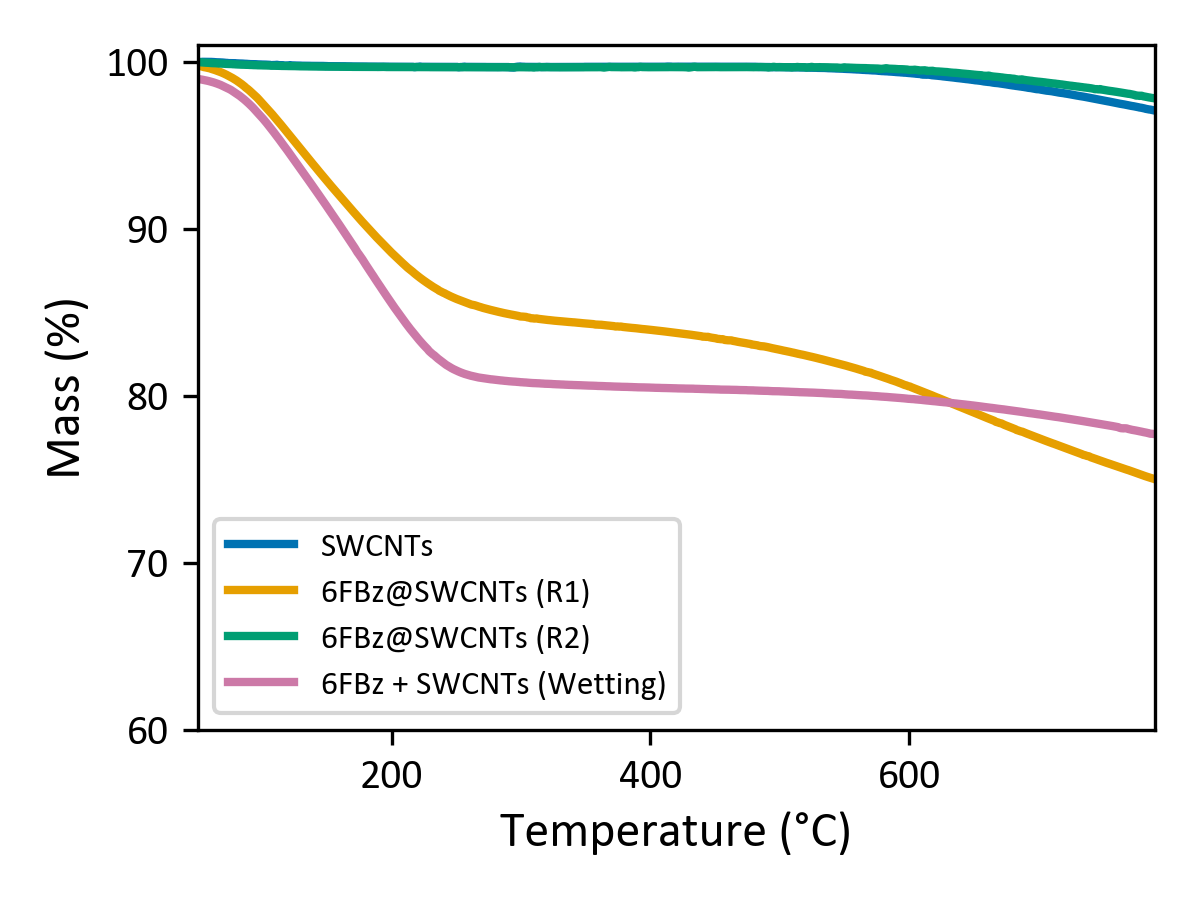

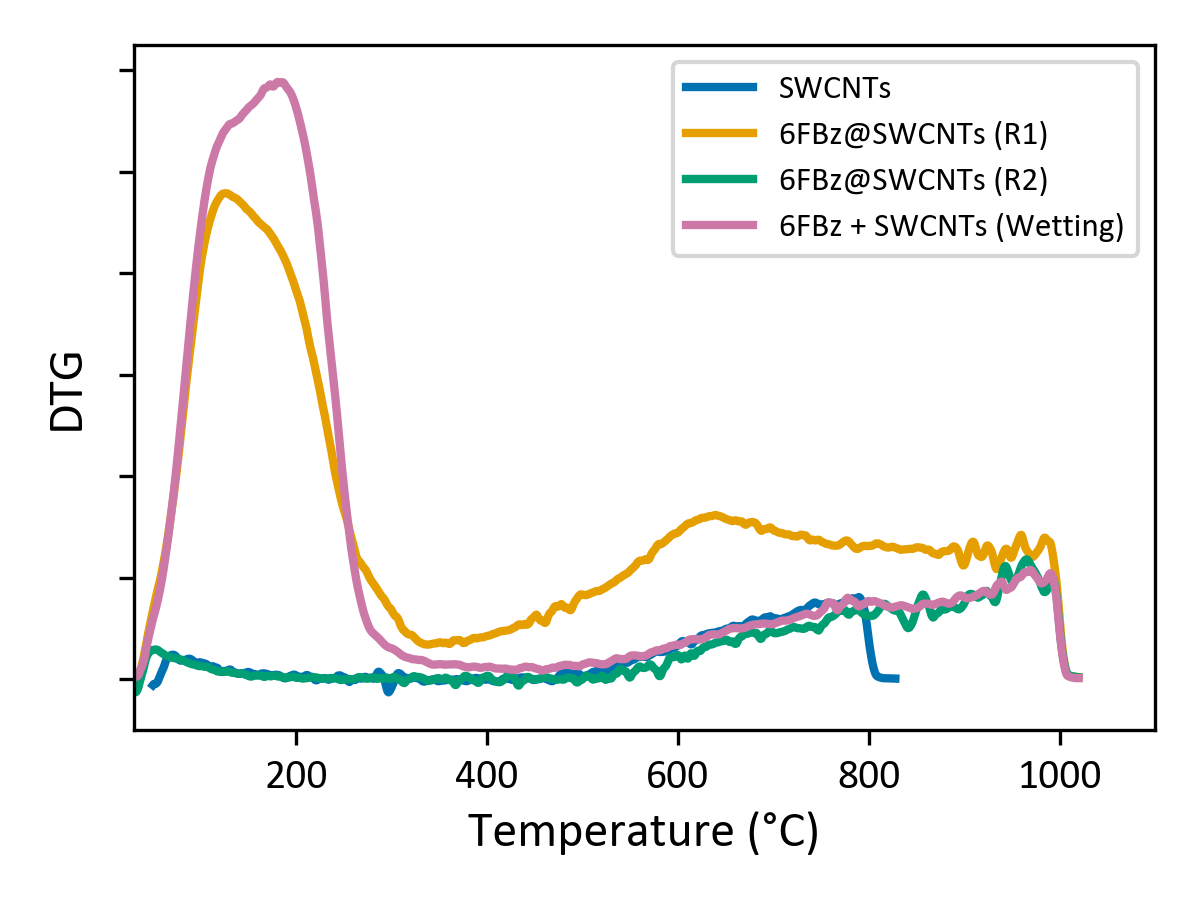

In [10]:
DFs = [#df_A_fixed, 
       #dfB,
         dfC,
           dfD,
             dfE,
               dfF
             ]

DF_labels = [
    #"P2 (Test)",
    #"P2 (R1)",
    "SWCNTs",

    "6FBz@SWCNTs (R1)",
    "6FBz@SWCNTs (R2)",
    "6FBz + SWCNTs (Wetting)"
]
save_dir = r"H:\FUBerlin\Writing and Summaries\6FBz@P2-SWCNTs\Figures"

TGA_DFs = [process_tga(df, label) for df, label in zip(DFs, DF_labels)]
plot_tga(TGA_DFs)
plt.savefig(
    save_dir + r"\TGA.png",
    dpi=300,
    bbox_inches="tight"
)
DTGA_DFs = [compute_dtg(df, smooth_window=10) for df in TGA_DFs]
plot_dtg(DTGA_DFs)
plt.savefig(
    save_dir + r"\DTGA.png",
    dpi=300,
    bbox_inches="tight"
)